# Retail Data Wrangling and Analytics

In [173]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Database
import os
from sqlalchemy import create_engine

# Notebook display
%matplotlib inline
sns.set_style("whitegrid")

# Load Data from PSQL into DataFrame

**Setup Docker Containers** - A bridge network called jrvs-net was created and verified so that jrvs-jupyter and jrvs-psql can communicate with each other

![](https://i.imgur.com/VQrBVBk.jpg)

**Data Load** - Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)


In [174]:
#install psql "driver"
!pip3 install psycopg2-binary

In [176]:
DB_USER = os.getenv("PGUSER", "postgres")
DB_PASS = os.getenv("PGPASSWORD", "password")
DB_HOST = os.getenv("PGHOST", "jrvs-psql")
DB_PORT = os.getenv("PGPORT", "5432")
DB_NAME = os.getenv("PGDATABASE", "postgres")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

query = "SELECT * FROM retail"
retail_df = pd.read_sql(query, engine)

In [177]:
print(f"Loaded {len(retail_df):,} rows × {retail_df.shape[1]} columns")

Loaded 1,067,371 rows × 8 columns


In [179]:
# Standardize columns
retail_df.columns = retail_df.columns.str.strip().str.lower()

In [180]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


# Dataset Overview

In [181]:
# Dataset size
# Dataset is at transaction line-item level (multiple rows per invoice)
num_rows, num_cols = retail_df.shape

# Time period
start_date = retail_df['invoice_date'].min().date()
end_date = retail_df['invoice_date'].max().date()

# Memory footprint
memory_mb = retail_df.memory_usage(deep=True).sum() / (1024 ** 2)

summary_df = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Start Date", "End Date", "Memory Usage (MB, deep)"],
    "Value": [num_rows, num_cols, start_date, end_date, round(memory_mb, 2)]
})

summary_df

,Metric,Value
0,Rows,1067371
1,Columns,8
2,Start Date,2009-12-01
3,End Date,2011-12-09
4,"Memory Usage (MB, deep)",316.55


# Standardisation and Deduplication

In [182]:
# Normalize key string fields (prevents undercounting cancellations, mismatched grouping)
retail_df["invoice_no"] = retail_df["invoice_no"].astype(str).str.strip()
retail_df["stock_code"] = retail_df["stock_code"].astype(str).str.strip()
retail_df["description"] = retail_df["description"].astype(str).str.strip()
retail_df["country"] = retail_df["country"].astype(str).str.strip()

# Robust cancellation flag (case-insensitive)
retail_df["is_cancelled"] = retail_df["invoice_no"].str.upper().str.startswith("C")

# Remove exact duplicate rows to prevent double-counting
rows_before = len(retail_df)
retail_df = retail_df.drop_duplicates().copy()
rows_after = len(retail_df)

print(f"Deduplication removed {rows_before - rows_after:,} rows ({(rows_before - rows_after)/rows_before*100:.2f}%). New total: {rows_after:,}")

Deduplication removed 34,335 rows (3.22%). New total: 1,033,036


# Data Quality Observations

In [154]:
num_cancellations = retail_df["is_cancelled"].sum()
cancellation_pct = round(num_cancellations / len(retail_df) * 100, 2)

num_cancellations, cancellation_pct

(19494, 1.83)

In [155]:
invalid_quantity = (retail_df["quantity"] <= 0).sum()
invalid_price = (retail_df["unit_price"] <= 0).sum()

invalid_quantity, invalid_price

(22950, 6207)

In [183]:
duplicate_count = retail_df.duplicated().sum()
duplicate_count

0

In [184]:
# Inconsistent descriptions per stock_code (exclude null descriptions so counts are meaningful)
description_variants = (
    retail_df.dropna(subset=["description"])
    .groupby("stock_code")["description"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
description_variants

stock_code
20713     10
23084      8
22734      8
21181      8
22423      8
47566B     7
22719      7
85175      7
21830      7
23131      6
Name: description, dtype: int64

In [185]:
# Convert invoice_date to datetime
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

In [186]:
# Separate cancellations
cancel_df = retail_df[retail_df["is_cancelled"]].copy()

In [187]:
# Filter valid sales
sales_df = retail_df[
    (~retail_df["is_cancelled"]) &
    (retail_df["quantity"] > 0) &
    (retail_df["unit_price"] > 0)
].copy()

In [188]:
# Revenue per line item (not per invoice)
sales_df["revenue"] = sales_df["quantity"] * sales_df["unit_price"]

In [189]:
non_cancel_invalid_qty = ((~retail_df["is_cancelled"]) & (retail_df["quantity"] <= 0)).sum()
print(f"Non-cancellation rows with quantity <= 0: {non_cancel_invalid_qty:,}")

Non-cancellation rows with quantity <= 0: 3,393


# Monthly Revenue Trend

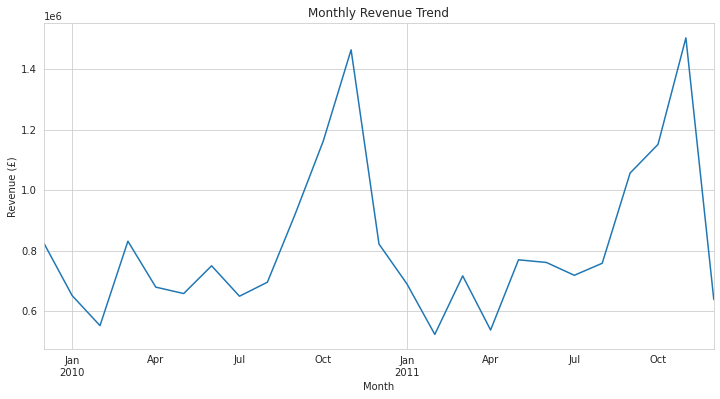

In [191]:
monthly_revenue = sales_df.resample('M', on='invoice_date')['revenue'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.show()

# Monthly Active Users

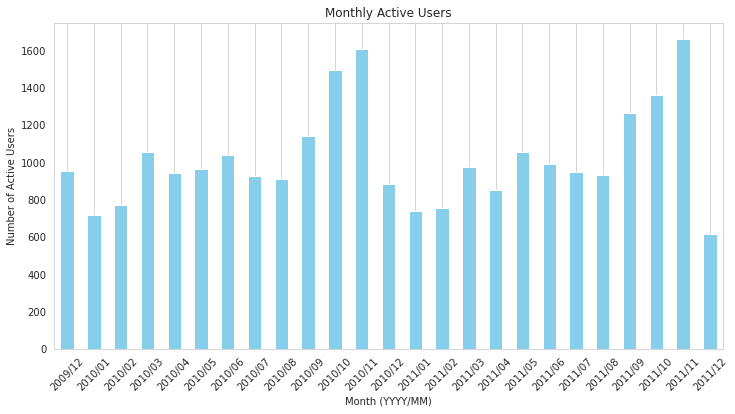

In [163]:
# Compute monthly active users
monthly_active_users = sales_df.groupby(pd.Grouper(key='invoice_date', freq='M'))['customer_id'].nunique()

# Format the index as YYYY/MM for x-axis
monthly_active_users.index = monthly_active_users.index.strftime('%Y/%m')

# Plot
plt.figure(figsize=(12,6))
monthly_active_users.plot(kind='bar', color='skyblue')
plt.title("Monthly Active Users")
plt.xlabel("Month (YYYY/MM)")
plt.ylabel("Number of Active Users")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# New vs Existing Users

Top 5 months by total active users (Exact):


user_type,Existing,New,Total
invoice_date,,,
2011-11,1473,191,1664
2010-11,1282,325,1607
2010-10,1120,377,1497
2011-10,1143,221,1364
2011-09,1077,189,1266


<Figure size 864x432 with 0 Axes>

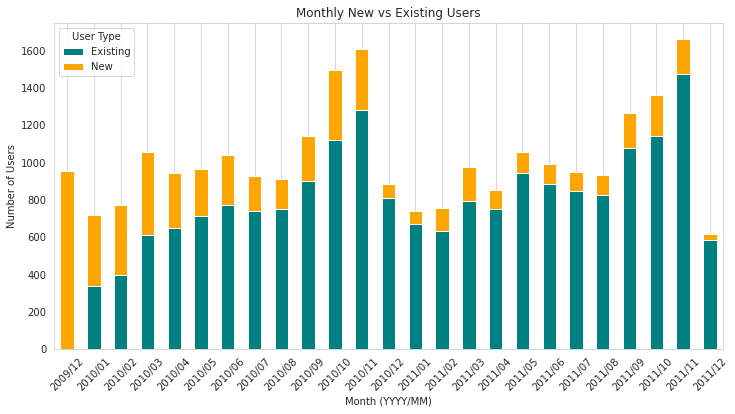

In [195]:
# Create a copy so we don't mutate sales_df used by other analyses
users_df = sales_df.copy()

# Identify first purchase month for each customer
first_purchase = (users_df.groupby("customer_id", as_index=False)["invoice_date"].min())

first_purchase["first_purchase_month"] = first_purchase["invoice_date"].dt.to_period("M")

# Merge first purchase month back onto transactions
users_df = users_df.merge(
    first_purchase[["customer_id", "first_purchase_month"]],
    on="customer_id",
    how="left"
)

# Assign user type for each transaction
users_df["user_type"] = np.where(
    users_df["invoice_date"].dt.to_period("M") == users_df["first_purchase_month"],
    "New",
    "Existing"
)

# Count unique new and existing users per month
monthly_users = (
    users_df.groupby([users_df["invoice_date"].dt.to_period("M"), "user_type"])["customer_id"]
    .nunique()
    .unstack(fill_value=0)
)

# -----------------
# Exact numbers output
# -----------------
monthly_users_out = monthly_users.copy()
monthly_users_out["Total"] = monthly_users_out.sum(axis=1)

print("Top 5 months by total active users (Exact):")
display(monthly_users_out.sort_values("Total", ascending=False).head(5))

# Plot
plot_df = monthly_users.copy()
plot_df.index = plot_df.index.astype(str).str.replace("-", "/")  # YYYY/MM for x-axis

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", stacked=True, figsize=(12, 6), color=["teal", "orange"])
plt.title("Monthly New vs Existing Users")
plt.xlabel("Month (YYYY/MM)")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.legend(title="User Type")
plt.grid(axis="y")
plt.show()

# Product Analysis - Sales vs Cancellations

,stock_code,description,sales_count,cancel_count,cancel_rate_pct
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5502,134,2.44
1,22423,REGENCY CAKESTAND 3 TIER,3950,341,8.63
2,85099B,JUMBO BAG RED RETROSPOT,3287,84,2.56
3,84879,ASSORTED COLOUR BIRD ORNAMENT,2848,19,0.67
4,47566,PARTY BUNTING,2705,23,0.85
5,20727,LUNCH BAG BLACK SKULL.,2402,45,1.87
6,21931,JUMBO STORAGE BAG SUKI,2352,34,1.45
7,21232,STRAWBERRY CERAMIC TRINKET BOX,2352,187,7.95
8,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,2209,22,1.00
9,22469,HEART OF WICKER SMALL,2195,19,0.87


,description,sales_count,cancel_count,cancel_rate_pct
1,REGENCY CAKESTAND 3 TIER,3950,341,8.63
7,STRAWBERRY CERAMIC TRINKET BOX,2352,187,7.95
2,JUMBO BAG RED RETROSPOT,3287,84,2.56
0,WHITE HANGING HEART T-LIGHT HOLDER,5502,134,2.44
12,LUNCH BAG CARS BLUE,2091,43,2.06
5,LUNCH BAG BLACK SKULL.,2402,45,1.87
6,JUMBO STORAGE BAG SUKI,2352,34,1.45
8,JUMBO SHOPPER VINTAGE RED PAISLEY,2209,22,1.00
13,HOME BUILDING BLOCK WORD,2087,20,0.96
11,LUNCH BAG SPACEBOY DESIGN,2128,20,0.94


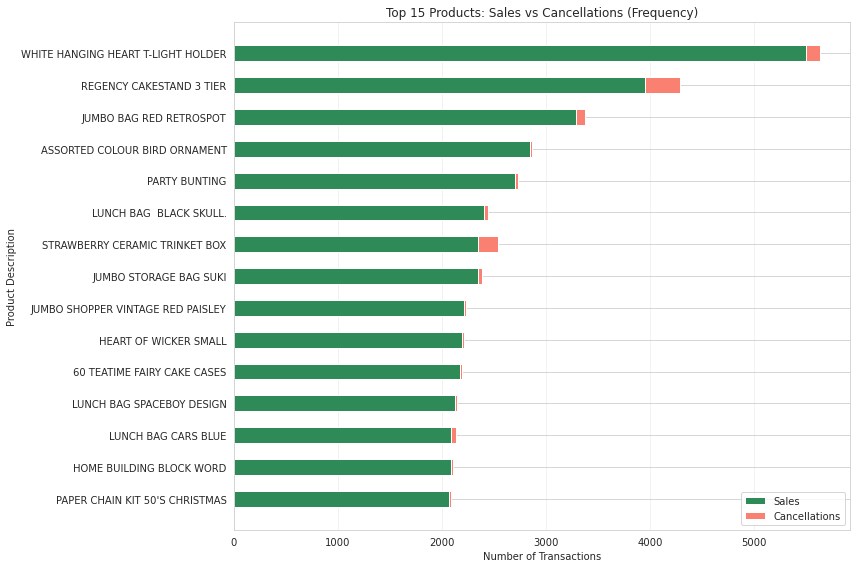

In [198]:
# -----------------------------
# 1. Clean cancellation data
# -----------------------------
cancel_df_clean = cancel_df[
    ~cancel_df['description'].isin(['Manual', 'POSTAGE', 'Discount', 'SAMPLES'])
]

# -----------------------------
# 2. Top 15 products by SALES FREQUENCY
# -----------------------------
top_selling_products = (
    sales_df
    .groupby(['stock_code', 'description'])
    .size()
    .reset_index(name='sales_count')
    .sort_values('sales_count', ascending=False)
    .head(15)
)

# -----------------------------
# 3. Cancellation frequency for same products
# -----------------------------
cancel_counts = (
    cancel_df_clean
    .groupby('stock_code')
    .size()
    .reset_index(name='cancel_count')
)

# -----------------------------
# 4. Merge sales & cancellations
product_summary = pd.merge(
    top_selling_products,
    cancel_counts,
    on='stock_code',
    how='left'
).fillna({'cancel_count': 0})

# -----------------------------
# 5. Sort for plotting
# -----------------------------
product_summary = product_summary.sort_values('sales_count')

#Output numbers
# Add cancellation rate + sort by cancellations
product_summary["cancel_rate_pct"] = (
    (product_summary["cancel_count"] / product_summary["sales_count"]) * 100
).round(2)

# Exact table (top 15 sellers, with cancellations + rate)
display(
    product_summary[["stock_code", "description", "sales_count", "cancel_count", "cancel_rate_pct"]]
    .sort_values(["sales_count"], ascending=False)
)

#Highest cancellation rate among top sellers
display(
    product_summary[["description", "sales_count", "cancel_count", "cancel_rate_pct"]]
    .sort_values("cancel_rate_pct", ascending=False)
)

# -----------------------------
# 6. Plot stacked bar chart
# -----------------------------
plt.figure(figsize=(12, 8))
bar_height = 0.5

plt.barh(
    product_summary['description'],
    product_summary['sales_count'],
    label='Sales',
    height = bar_height,
    color='seagreen'
)

plt.barh(
    product_summary['description'],
    product_summary['cancel_count'],
    left=product_summary['sales_count'],
    label='Cancellations',
    height = bar_height,
    color='salmon'
)

# -----------------------------
# 7. Formatting
# -----------------------------
plt.title("Top 15 Products: Sales vs Cancellations (Frequency)")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Cancellation Risk vs Revenue Impact

Top 6 months by LOST REVENUE (£):


,cancel_rate_pct,lost_revenue,lost_rev_pct_of_sales,total_revenue,total_orders,cancelled_orders
invoice_date,,,,,,
2011-12,14.598540,204614.80,32.080923,637808.33,819,140
2011-01,18.712575,125970.19,18.261535,689811.61,1086,250
2010-12,16.541756,71394.52,8.691251,821452.70,1559,309
2011-10,13.522679,58555.91,5.086229,1151263.73,2040,319
2011-08,15.413300,46189.26,6.094845,757841.42,1361,248
2011-11,12.732430,43065.44,2.863647,1503866.78,2769,404



Top 6 months by CANCELLATION RATE (%):


,cancel_rate_pct,lost_revenue,lost_rev_pct_of_sales,total_revenue,total_orders,cancelled_orders
invoice_date,,,,,,
2010-05,20.718816,38538.46,5.859531,657705.500,1500,392
2010-01,19.694767,9634.82,1.479651,651155.112,1105,271
2011-01,18.712575,125970.19,18.261535,689811.610,1086,250
2009-12,18.468250,20421.51,2.482907,822483.950,1682,381
2010-03,17.557626,10661.90,1.283151,830915.261,1681,358
2010-07,17.127371,17755.75,2.736663,648810.270,1529,316


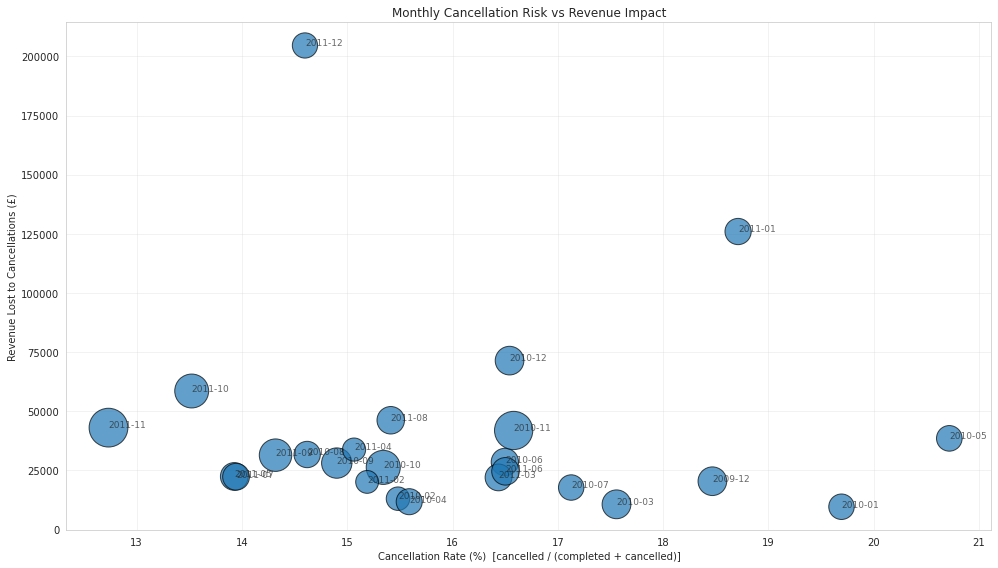

In [199]:
cancel_df_clean = cancel_df_clean.copy()

# Lost revenue (treat cancellation quantity as negative/return; take absolute value)
cancel_df_clean["lost_revenue"] = cancel_df_clean["quantity"].abs() * cancel_df_clean["unit_price"]

# Monthly cancellations: count cancelled invoices + lost revenue
monthly_cancel = (
    cancel_df_clean.groupby(pd.Grouper(key="invoice_date", freq="M"))
    .agg(
        cancelled_orders=("invoice_no", "nunique"),
        lost_revenue=("lost_revenue", "sum")
    )
)

# Monthly completed orders & revenue (valid sales only)
monthly_total = (
    sales_df.groupby(pd.Grouper(key="invoice_date", freq="M"))
    .agg(
        total_orders=("invoice_no", "nunique"),
        total_revenue=("revenue", "sum")
    )
)

# Combine
monthly_cancel_analysis = (
    monthly_total.merge(monthly_cancel, left_index=True, right_index=True, how="left")
    .fillna({"cancelled_orders": 0, "lost_revenue": 0})
)

# Cancellation rate: cancelled / (completed + cancelled)
monthly_cancel_analysis["all_orders"] = (
    monthly_cancel_analysis["total_orders"] + monthly_cancel_analysis["cancelled_orders"]
)

monthly_cancel_analysis["cancel_rate_pct"] = np.where(
    monthly_cancel_analysis["all_orders"] > 0,
    (monthly_cancel_analysis["cancelled_orders"] / monthly_cancel_analysis["all_orders"]) * 100,
    0
)

# Revenue impact as % of sales revenue
monthly_cancel_analysis["lost_rev_pct_of_sales"] = np.where(
    monthly_cancel_analysis["total_revenue"] > 0,
    (monthly_cancel_analysis["lost_revenue"] / monthly_cancel_analysis["total_revenue"]) * 100,
    0
)

# -----------------------------
# Exact numbers outputs
# -----------------------------
out = monthly_cancel_analysis.copy()
out.index = out.index.strftime("%Y-%m")

print("Top 6 months by LOST REVENUE (£):")
display(
    out.sort_values("lost_revenue", ascending=False)[
        ["cancel_rate_pct", "lost_revenue", "lost_rev_pct_of_sales", "total_revenue", "total_orders", "cancelled_orders"]
    ].head(6)
)

print("\nTop 6 months by CANCELLATION RATE (%):")
display(
    out.sort_values("cancel_rate_pct", ascending=False)[
        ["cancel_rate_pct", "lost_revenue", "lost_rev_pct_of_sales", "total_revenue", "total_orders", "cancelled_orders"]
    ].head(6)
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(14, 8))

plt.scatter(
    monthly_cancel_analysis["cancel_rate_pct"],
    monthly_cancel_analysis["lost_revenue"],
    s=monthly_cancel_analysis["total_revenue"] / 1000,  # bubble size scale
    alpha=0.7,
    edgecolors="black"
)

for date, row in monthly_cancel_analysis.iterrows():
    plt.text(
        row["cancel_rate_pct"],
        row["lost_revenue"],
        date.strftime("%Y-%m"),
        fontsize=9,
        alpha=0.7
    )

plt.xlabel("Cancellation Rate (%)  [cancelled / (completed + cancelled)]")
plt.ylabel("Revenue Lost to Cancellations (£)")
plt.title("Monthly Cancellation Risk vs Revenue Impact")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Share of Revenue Lost

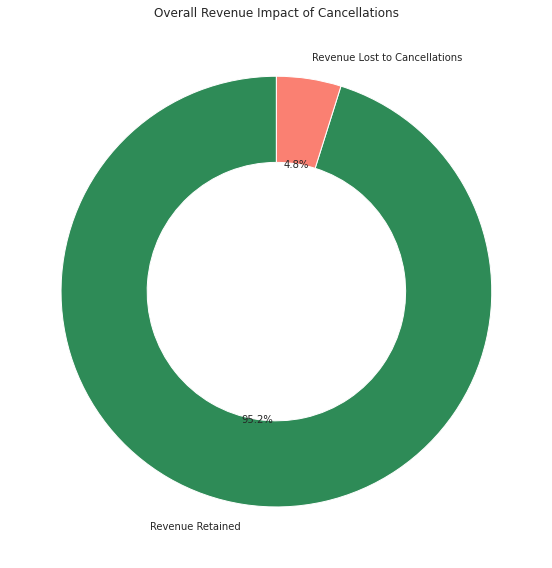

In [168]:
lost = monthly_cancel_analysis['lost_revenue'].sum()
retained = monthly_cancel_analysis['total_revenue'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    [retained, lost],
    labels=['Revenue Retained', 'Revenue Lost to Cancellations'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['seagreen', 'salmon'],
    wedgeprops={'width': 0.4}
)

plt.title("Overall Revenue Impact of Cancellations")
plt.tight_layout()
plt.show()

# Revenue by Country (Geography Analysis)

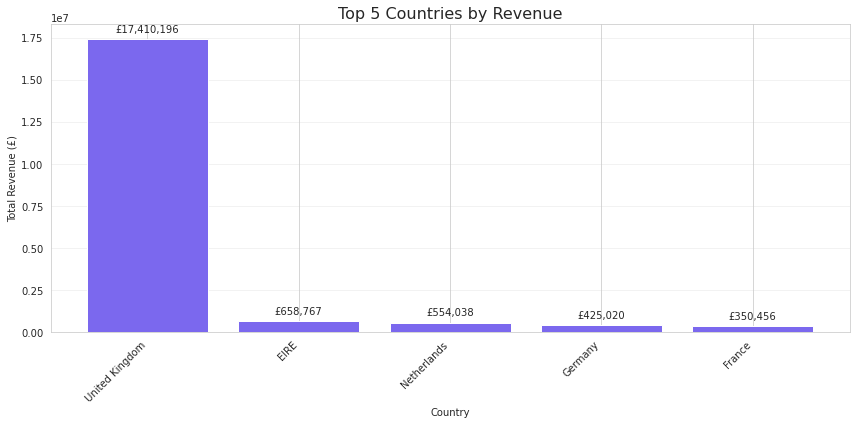

In [200]:
# -----------------------------
# Revenue by Country (Top 10)
# -----------------------------
country_revenue = sales_df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_countries = country_revenue.head(5)  # Focus on top 10 countries

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))
bars = plt.bar(top_countries.index, top_countries.values, color='mediumslateblue')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'£{height:,.0f}', 
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # Offset label a bit above the bar
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Titles and labels
plt.title("Top 5 Countries by Revenue", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Average Order Value (AOV) - Monthly

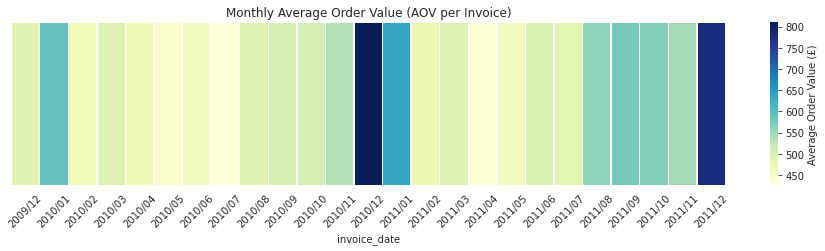

In [170]:
# 1) Build invoice-level totals (one row per invoice)
invoice_df = sales_df.groupby('invoice_no').agg(
    invoice_revenue=('revenue', 'sum'),
    invoice_date=('invoice_date', 'first')   # use first (or min) invoice timestamp
).reset_index()

# 2) Monthly AOV per invoice
monthly_aov = invoice_df.resample('M', on='invoice_date')['invoice_revenue'].mean()

# 3) Convert to DataFrame for heatmap layout
monthly_aov_df = monthly_aov.to_frame().T
monthly_aov_df.columns = monthly_aov_df.columns.strftime('%Y/%m')

# 4) Plot clean heatmap (no numbers)
plt.figure(figsize=(16,3))
sns.heatmap(
    monthly_aov_df,
    cmap='YlGnBu',
    cbar_kws={'label': 'Average Order Value (£)'},
    annot=False,
    linewidths=0.5,
    linecolor='white'
)
plt.title("Monthly Average Order Value (AOV per Invoice)")
plt.yticks([])       # hide the single row label
plt.xticks(rotation=45)
plt.show()